## Load data

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt

In [2]:
# import pandas as pd
# from WindPy import w
#
# w.start()
#
# CODE = "IVIX.SH"
# START = "1990-01-01"   # 足够早，Wind会自动从可得最早日返回
# END = pd.Timestamp.today().strftime("%Y-%m-%d")
#
# r = w.wsd(CODE, "close", START, END, "PriceAdj=F")
# if r.ErrorCode != 0:
#     raise RuntimeError(f"Wind wsd failed, ErrorCode={r.ErrorCode}")
#
# ivix_df = pd.DataFrame({
#     "date": pd.to_datetime(r.Times),
#     "ivix": r.Data[0],
# }).dropna()
#
# ivix_df = (
#     ivix_df.drop_duplicates(subset=["date"])
#            .sort_values("date")
#            .reset_index(drop=True)
# )
#
# out_path = "IVIX_SH.csv"
# ivix_df.to_csv(out_path, index=False, encoding="utf-8-sig")
#
# print("Saved:", out_path)
# print("Start:", ivix_df["date"].min(), "End:", ivix_df["date"].max(), "Rows:", len(ivix_df))

In [3]:
# from WindPy import w
# import pandas as pd
#
# w.start()
#
# # 拉取万得全A指数收盘价
# data = w.wsd(
#     "881001.WI",          # 万得全A
#     "close",              # 收盘价
#     "1990-01-01",         # 起始日期（你可以按需改）
#     "",                   # 结束日期：空字符串 = 今天
#     "PriceAdj=F"          # 不复权（指数本身不需要复权）
# )
#
# # 转成 DataFrame
# wind_allA = pd.DataFrame({
#     "date": pd.to_datetime(data.Times),
#     "close": data.Data[0]
# }).dropna()
# wind_allA.to_csv("WIND_ALLA_881001.csv", index=False)

In [4]:
def load_panel_from_wind_parquet(
    parquet_path: str,
    etf_pool_xlsx: str,
    use_adj: bool = False,   # ETF：建议默认 False
) -> pd.DataFrame:

    pool = pd.read_excel(etf_pool_xlsx)
    universe = sorted(pool["S_INFO_WINDCODE"].dropna().unique().tolist())

    cols = [
        "S_INFO_WINDCODE",
        "TRADE_DT",
        "S_DQ_CLOSE",
        "S_DQ_ADJCLOSE",
        "S_DQ_VOLUME",
        "S_DQ_TRADESTATUS",
        "S_DQ_TRADESTATUSCODE",   # 保留
    ]

    pf = pq.ParquetFile(parquet_path)
    chunks = []
    for rg in range(pf.num_row_groups):
        chunks.append(pf.read_row_group(rg, columns=cols).to_pandas())
    raw = pd.concat(chunks, ignore_index=True)

    raw = raw.rename(columns={
        "S_INFO_WINDCODE": "code",
        "TRADE_DT": "date",
        "S_DQ_CLOSE": "close",
        "S_DQ_ADJCLOSE": "adj_close",
        "S_DQ_VOLUME": "volume",
        "S_DQ_TRADESTATUS": "trade_status",
        "S_DQ_TRADESTATUSCODE": "trade_status_code",
    })

    # 日期：yyyymmdd
    raw["date"] = pd.to_datetime(raw["date"].astype(str), format="%Y%m%d", errors="coerce")
    raw = raw.dropna(subset=["date", "code"])

    # ETF universe 过滤
    raw = raw[raw["code"].isin(universe)].copy()

    # 交易状态过滤：优先用字符串字段（最可靠）
    if "trade_status" in raw.columns and raw["trade_status"].notna().any():
        raw = raw[raw["trade_status"].astype(str).str.contains("交易", na=False)].copy()
    # 若没有 trade_status 字段，就不要强行假设 code==1 才交易（不同库/不同表编码差异很大）
    # 你也可以在这里按自己数据字典再加规则

    # 价格选择：ETF 默认 close（不复权）
    if use_adj and raw["adj_close"].notna().any():
        raw["close_use"] = raw["adj_close"]
    else:
        raw["close_use"] = raw["close"]

    # 数值化 + 清洗（关键）
    raw["close_use"] = pd.to_numeric(raw["close_use"], errors="coerce")
    raw["volume"] = pd.to_numeric(raw["volume"], errors="coerce")

    raw = raw.dropna(subset=["close_use", "volume"])
    raw = raw[(raw["close_use"] > 0) & (raw["volume"] > 0)].copy()

    panel = raw[["date", "code", "close_use", "volume"]].rename(columns={"close_use": "close"})
    panel = panel.sort_values(["code", "date"]).reset_index(drop=True)

    return panel

In [5]:
panel = load_panel_from_wind_parquet('ChinaClosedFundEODPrice.parquet', 'etf_pool_data.xlsx', use_adj=False)

In [6]:
panel.groupby("date")["code"].nunique().describe()

count    5056.000000
mean      229.370253
std       331.883383
min         1.000000
25%         9.000000
50%        81.000000
75%       269.000000
max      1339.000000
Name: code, dtype: float64

## Price-Volume Factors

In [7]:
from pandas.tseries.offsets import MonthEnd

def _winsorize(s: pd.Series, p: float = 0.01, min_n: int = 15) -> pd.Series:
    s = pd.to_numeric(s, errors="coerce").astype(float)
    if s.notna().sum() < min_n:
        return s
    lo = s.quantile(p)
    hi = s.quantile(1 - p)
    if not np.isfinite(lo) or not np.isfinite(hi) or lo >= hi:
        return s
    return s.clip(lo, hi)

def _zscore_robust(s: pd.Series, min_n: int = 15, clip: float = 5.0) -> pd.Series:
    s = pd.to_numeric(s, errors="coerce").astype(float)
    if s.notna().sum() < min_n:
        return pd.Series(np.nan, index=s.index)

    med = s.median(skipna=True)
    mad = (s - med).abs().median(skipna=True)
    if not np.isfinite(mad) or mad == 0:
        return pd.Series(np.nan, index=s.index)

    z = (s - med) / (1.4826 * mad)
    return z.clip(-clip, clip) if clip is not None else z

def _to_month_end(d: pd.Series) -> pd.Series:
    d = pd.to_datetime(d)
    return (d + MonthEnd(0)).dt.normalize()

def _to_week_end(d: pd.Series) -> pd.Series:
    d = pd.to_datetime(d)
    return d.dt.to_period("W-FRI").dt.to_timestamp("W-FRI").dt.normalize()

def compute_price_volume_factors(
    panel: pd.DataFrame,
    price_col: str = "close",
    vol_col: str = "volume",
) -> pd.DataFrame:
    df = panel.copy()
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values(["code", "date"])

    # 基础数据清洗
    df[price_col] = pd.to_numeric(df[price_col], errors="coerce")
    df[vol_col]   = pd.to_numeric(df[vol_col], errors="coerce")
    df = df.dropna(subset=[price_col, vol_col])

    # 1. 基础收益与波动
    df["ret_1d"] = df.groupby("code")[price_col].pct_change()
    v = df.groupby("code")[vol_col].transform(lambda x: np.log(x.replace(0, np.nan)))
    df["vol_chg"] = df.groupby("code")[v.name].diff()


    # 2. 动量 (Momentum) - 保持不变
    df["price_mom"] = df.groupby("code")[price_col].transform(
        lambda x: x.pct_change(20)  # 20日动量
    )

    # 3. 趋势 (Trend) - 保持不变
    df["ma_60"] = df.groupby("code")[price_col].transform(lambda x: x.rolling(60).mean())
    df["price_trend"] = df[price_col] / df["ma_60"] - 1.0

    # === 新增量价特征 ===

    # 4. 量价相关性 (PV Correlation)
    # 逻辑：涨的时候放量，跌的时候缩量 -> 正相关 -> 好
    # 窗口设为 10-15 天，反应灵敏
    df["pv_corr"] = df.groupby("code").apply(
        lambda x: x["ret_1d"].rolling(12).corr(x["vol_chg"])
    ).reset_index(0, drop=True)

    # 5. 相对放量 (RVol - Relative Volume)
    # 逻辑：当前量 / 过去20天均量
    df["vol_ma_20"] = df.groupby("code")[vol_col].transform(lambda x: x.rolling(20).mean())
    df["rvol"] = df[vol_col] / df["vol_ma_20"]

    # 6. 波动率 (用于后续防守)
    df["volatility"] = df.groupby("code")["ret_1d"].transform(
        lambda x: x.rolling(20).std()
    )

    # 数据清洗：去极值、填充
    factors = ["price_mom", "price_trend", "pv_corr", "rvol"]
    for c in factors:
        # 简单去极值，防止 inf
        df[c] = df[c].replace([np.inf, -np.inf], np.nan)
        # 也可以在这里做 winsorize

    # 为了防止当天的量价数据还没产生收益就用，通常因子要滞后一天（或者在回测时滞后）
    # 但在打分计算时，我们可以用当天的状态来决定明天买不买

    return df.dropna(subset=factors)

In [8]:
panel_with_factors = compute_price_volume_factors(panel)

In [9]:
meta = pd.read_csv("etf_pool_data.csv")
meta = meta.dropna(subset=["S_INFO_WINDCODE", "ETF_CLASS_NAME"])
meta = meta.sort_values("ENTRY_DT").drop_duplicates("S_INFO_WINDCODE", keep="last")
meta = meta.rename(columns={"S_INFO_WINDCODE": "code"})

panel_with_factors = panel_with_factors.merge(
    meta[["code", "ETF_CLASS_NAME"]],
    on="code",
    how="left"
)
panel_with_factors

,date,code,close,volume,ret_1d,vol_chg,price_mom,ma_60,price_trend,pv_corr,vol_ma_20,rvol,volatility,ETF_CLASS_NAME
0,2025-12-04,159101.SZ,0.967,4392219.64,0.014690,1023552.55,-0.053816,1.033183,-0.064058,-0.011617,2.852907e+06,1.539559,0.013384,跨境ETF
1,2025-12-05,159101.SZ,0.976,4832402.13,0.009307,440182.49,-0.027888,1.032967,-0.055149,-0.018848,2.968367e+06,1.627966,0.013155,跨境ETF
2,2025-12-08,159101.SZ,0.974,4029710.43,-0.002049,-802691.70,-0.045098,1.032417,-0.056582,0.064142,3.053255e+06,1.319808,0.012512,跨境ETF
3,2025-12-09,159101.SZ,0.958,3757608.98,-0.016427,-272101.45,-0.057087,1.031433,-0.071195,0.210681,3.173898e+06,1.183910,0.012907,跨境ETF
4,2025-12-10,159101.SZ,0.963,6423820.11,0.005219,2666211.13,-0.059570,1.030300,-0.065321,0.344430,3.400361e+06,1.889159,0.012804,跨境ETF
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1082825,2025-12-04,589990.SH,1.274,27230.00,0.007911,-3357.00,-0.056995,1.316833,-0.032528,0.081672,6.330815e+04,0.430118,0.012407,规模指数ETF
1082826,2025-12-05,589990.SH,1.285,41302.00,0.008634,14072.00,-0.041760,1.318317,-0.025272,0.170130,6.329860e+04,0.652495,0.012615,规模指数ETF
1082827,2025-12-08,589990.SH,1.310,36032.00,0.019455,-5270.00,-0.018727,1.319500,-0.007200,0.104471,6.195530e+04,0.581581,0.013478,规模指数ETF
1082828,2025-12-09,589990.SH,1.305,24497.00,-0.003817,-11535.00,-0.017319,1.320317,-0.011601,0.465870,5.925985e+04,0.413383,0.013458,规模指数ETF


In [10]:
mkt = panel_with_factors.groupby("date").agg(
    cs_trend=("price_trend", "median"),
    cs_mom=("price_mom", "median"),
    cs_pv=("pv_corr", "median"),
    cs_rvol=("rvol", "median"),
    breadth_up=("ret_1d", lambda x: (x > 0).mean()),
).sort_index()

# 平滑一下，避免 regime 频繁翻转
mkt["cs_trend_s"] = mkt["cs_trend"].ewm(span=20, min_periods=10).mean()
mkt["cs_pv_s"]    = mkt["cs_pv"].ewm(span=10, min_periods=5).mean()
ivix = pd.read_csv("IVIX_SH.csv", parse_dates=["date"])
ivix = (
    ivix[["date", "ivix"]]
    .dropna()
    .drop_duplicates("date")
    .sort_values("date")
    .set_index("date")
)
mkt = mkt.join(ivix, how="left")
mkt["ivix"] = mkt["ivix"].ffill()
roll = 252
mu = mkt["ivix"].rolling(roll, min_periods=120).mean()
sd = mkt["ivix"].rolling(roll, min_periods=120).std()
mkt["ivix_z"] = (mkt["ivix"] - mu) / sd

In [11]:
# --- Regime labeling (ivix_z + jump + confirmation) ---

# 冲击：5日跳升
ivix_jump = mkt["ivix"] / mkt["ivix"].shift(5) - 1.0

mkt["regime"] = "neutral"

# risk_off：波动率显著偏高 或 出现冲击 或 趋势显著转弱
mkt.loc[
    (mkt["ivix_z"] >= 1.0) |
    (ivix_jump >= 0.35) |
    (mkt["cs_trend_s"] < -0.0075),
    "regime"
] = "risk_off"

# risk_on：波动率偏低 + 趋势为正 + 量价确认
mkt.loc[
    (mkt["ivix_z"] <= -0.3) &
    (mkt["cs_trend_s"] > 0.005) &
    (mkt["cs_pv_s"] > 0.0),
    "regime"
] = "risk_on"

In [12]:
CLASS_TO_BUCKET = {
    # China equity / risk
    "股票型ETF": "risk_cn",
    "规模指数ETF": "risk_cn",
    "行业指数ETF": "risk_cn",
    "主题指数ETF": "risk_cn",
    "风格指数ETF": "risk_cn",
    "策略指数ETF": "risk_cn",

    # Defensive
    "债券型ETF": "def_bond",

    # Real assets
    "商品型ETF": "real_asset",

    # Offshore
    "跨境ETF": "offshore",
    "跨境行业指数ETF": "offshore",
    "跨境主题指数ETF": "offshore",
    "跨境规模指数ETF": "offshore",
    "跨境策略指数ETF": "offshore",
}

panel_with_factors["bucket"] = panel_with_factors["ETF_CLASS_NAME"].map(CLASS_TO_BUCKET)

In [13]:
panel_with_factors

,date,code,close,volume,ret_1d,vol_chg,price_mom,ma_60,price_trend,pv_corr,vol_ma_20,rvol,volatility,ETF_CLASS_NAME,bucket
0,2025-12-04,159101.SZ,0.967,4392219.64,0.014690,1023552.55,-0.053816,1.033183,-0.064058,-0.011617,2.852907e+06,1.539559,0.013384,跨境ETF,offshore
1,2025-12-05,159101.SZ,0.976,4832402.13,0.009307,440182.49,-0.027888,1.032967,-0.055149,-0.018848,2.968367e+06,1.627966,0.013155,跨境ETF,offshore
2,2025-12-08,159101.SZ,0.974,4029710.43,-0.002049,-802691.70,-0.045098,1.032417,-0.056582,0.064142,3.053255e+06,1.319808,0.012512,跨境ETF,offshore
3,2025-12-09,159101.SZ,0.958,3757608.98,-0.016427,-272101.45,-0.057087,1.031433,-0.071195,0.210681,3.173898e+06,1.183910,0.012907,跨境ETF,offshore
4,2025-12-10,159101.SZ,0.963,6423820.11,0.005219,2666211.13,-0.059570,1.030300,-0.065321,0.344430,3.400361e+06,1.889159,0.012804,跨境ETF,offshore
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1082825,2025-12-04,589990.SH,1.274,27230.00,0.007911,-3357.00,-0.056995,1.316833,-0.032528,0.081672,6.330815e+04,0.430118,0.012407,规模指数ETF,risk_cn
1082826,2025-12-05,589990.SH,1.285,41302.00,0.008634,14072.00,-0.041760,1.318317,-0.025272,0.170130,6.329860e+04,0.652495,0.012615,规模指数ETF,risk_cn
1082827,2025-12-08,589990.SH,1.310,36032.00,0.019455,-5270.00,-0.018727,1.319500,-0.007200,0.104471,6.195530e+04,0.581581,0.013478,规模指数ETF,risk_cn
1082828,2025-12-09,589990.SH,1.305,24497.00,-0.003817,-11535.00,-0.017319,1.320317,-0.011601,0.465870,5.925985e+04,0.413383,0.013458,规模指数ETF,risk_cn


In [14]:
def build_rank_score(
    df: pd.DataFrame,
    min_cs_default: int = 4,
    group_col: str | None = "bucket",
) -> pd.Series:
    score = pd.Series(np.nan, index=df.index)

    group_keys = ["date"] + ([group_col] if (group_col and group_col in df.columns) else [])

    for _, g in df.groupby(group_keys):
        need = ["price_mom", "price_trend", "pv_corr", "rvol"]
        gv = g.dropna(subset=[c for c in need if c in g.columns]).copy()
        if len(gv) < min_cs_default:
            continue

        # 核心横截面强弱：mom + trend
        rk_mom   = gv["price_mom"].rank(pct=True)
        rk_trend = gv["price_trend"].rank(pct=True)
        xs_core  = 0.7 * rk_mom + 0.3 * rk_trend

        # 价量确认（软惩罚、连续）
        pv = gv["pv_corr"].astype(float)
        pv_score = pv.rank(pct=True)  # 0~1，越大越确认

        r = gv["rvol"].astype(float).clip(lower=1e-6)
        r_pen = np.clip(np.abs(np.log(r)), 0, 1.0)  # r=1最好
        r_score = 1.0 - r_pen

        confirm = 0.8 + 0.1 * (pv_score - 0.5) + 0.1 * (r_score - 0.5)
        confirm = confirm.clip(0.7, 1.0)

        score.loc[gv.index] = xs_core * confirm

    return score
# 生成分数
panel_with_factors["score"] = build_rank_score(panel_with_factors, group_col="bucket")

In [15]:
# Long-only 不同 regime 下的 bucket 配比
REGIME_BUCKET_W = {
    "risk_on":  {"risk_cn": 0.75, "offshore": 0.15, "real_asset": 0.10, "def_bond": 0.00},
    "neutral":  {"risk_cn": 0.55, "offshore": 0.10, "real_asset": 0.15, "def_bond": 0.20},
    "risk_off": {"risk_cn": 0.10, "offshore": 0.00, "real_asset": 0.25, "def_bond": 0.65},
}

In [24]:
def make_bucketed_longonly_weights(
    df: pd.DataFrame,
    mkt: pd.DataFrame,
    freq: str = "W",
    top_frac: float = 0.30,
    top_n_min: int = 3,
    min_universe_bucket: int = 2,
    gross: float = 1.0,
    weight_mode: str = "inv_vol",
    vol_window: int = 44,
    vol_min_periods: int = 22,
) -> pd.DataFrame:
    x = df.copy()
    x["date"] = pd.to_datetime(x["date"])
    x = x.dropna(subset=["bucket", "score", "ret_1d"]).sort_values(["code", "date"])

    # 估计每只ETF的实现波动（用于 inv_vol）
    x["vol_est"] = (
        x.groupby("code")["ret_1d"]
         .transform(lambda s: s.rolling(vol_window, min_periods=vol_min_periods).std(ddof=0) * np.sqrt(252))
    )

    dates = pd.DatetimeIndex(x["date"].unique()).sort_values()

    # ✅ 周频：每周最后一个交易日（替代硬锁周五）
    if freq.upper().startswith("W"):
        ds = pd.Series(dates)
        reb_dates = ds.groupby([ds.dt.year, ds.dt.isocalendar().week]).max().values
        reb_dates = pd.DatetimeIndex(reb_dates).sort_values()
    elif freq.upper().startswith("M"):
        ds = pd.Series(dates)
        reb_dates = ds.groupby([ds.dt.year, ds.dt.month]).max().values
        reb_dates = pd.DatetimeIndex(reb_dates).sort_values()
    else:
        raise ValueError("freq must be 'W' or 'M'")

    out = []
    mkt = mkt.copy()
    mkt.index = pd.to_datetime(mkt.index)

    for rd in reb_dates:
        # regime as-of rd
        mkt_slice = mkt.loc[mkt.index <= rd, "regime"]
        regime = mkt_slice.iloc[-1] if len(mkt_slice) else "neutral"
        bucket_w = REGIME_BUCKET_W.get(regime, REGIME_BUCKET_W["neutral"])

        # 用截至 rd 的最新一条（asof），避免当日缺数据造成抖动
        snap = x[x["date"] <= rd].sort_values("date").groupby("code").tail(1).copy()
        if len(snap) == 0:
            continue

        for b, bw in bucket_w.items():
            if bw <= 0:
                continue

            gb = snap[snap["bucket"] == b].dropna(subset=["score"])
            if gb["code"].nunique() < min_universe_bucket:
                continue

            k = max(top_n_min, int(np.ceil(len(gb) * top_frac)))
            pick = gb.nlargest(k, "score").copy()

            if weight_mode == "equal":
                pick["w_in"] = 1.0 / len(pick)
            else:
                v = pick["vol_est"].replace(0, np.nan)
                inv = 1.0 / v
                inv = inv.replace([np.inf, -np.inf], np.nan).fillna(inv.median())

                # 更稳健的上限
                cap = inv.quantile(0.90) * 2.0
                inv = inv.clip(upper=cap)

                pick["w_in"] = inv / inv.sum()

            pick["reb_date"] = rd
            pick["weight"] = pick["w_in"] * (gross * bw)
            out.append(pick[["reb_date", "code", "weight"]])

    if not out:
        return pd.DataFrame(columns=["reb_date", "code", "weight"])

    return pd.concat(out, ignore_index=True)

In [25]:
weights_final = make_bucketed_longonly_weights(
    df=panel_with_factors,
    mkt=mkt,
    freq="W",            # 周频
    top_frac=0.30,
    top_n_min=3,
    min_universe_bucket=2,
    gross=1.0,
    weight_mode="inv_vol",
    vol_window=44,
    vol_min_periods=22,
)

weights_final.head()

,reb_date,code,weight
0,2006-12-08,159901.SZ,NaN
1,2006-12-08,510180.SH,NaN
2,2006-12-08,510050.SH,NaN
3,2006-12-15,510180.SH,NaN
4,2006-12-15,159901.SZ,NaN


In [26]:
def backtest_from_weights(
    panel: pd.DataFrame,
    weights: pd.DataFrame,
    price_col: str = "close",
    cost_bps: float = 5.0,          # 单边 bps，双边交易通过 0.5*|Δw| 体现
    exec_lag: int = 1,              # T+1 生效（推荐=1）
    clip_ret: float = -0.95,        # 防止净值被单日 -100% 打穿
    # -------------------------
    # Risk overlays
    # -------------------------
    target_vol: float | None = 0.12,     # 年化目标波动（None 表示不控波动）
    vol_lookback: int = 22,             # 波动估计窗口（交易日）
    vol_min_periods: int = 22,          # 最小样本
    vol_cap: float = 1.0,               # 不加杠杆：最大缩放=1；想允许杠杆可 >1

    dd_limit: float | None = 0.1,      # 最大回撤阈值（None 表示不控回撤）
    dd_cooldown_scale: float = 0.3,     # 触发回撤后仓位缩到多少（0=空仓）
    dd_release: float = 0.05,           # 回撤修复到该水平以内解除
    # -------------------------
    # Cash bucket
    # -------------------------
    cash_gross_target: float = 1.0,          # 目标总gross exposure（通常=1）
    rf_annual_const: float | None = 0.03,    # 常数年化rf（可设None）
    rf_daily: pd.Series | None = None,       # 按日rf序列（优先级更高）
    rf_is_annual_rate: bool = False,         # rf_daily若是“年化利率”而非“日收益”，设True
    trading_days: int = 252,
) -> pd.DataFrame:
    """
    Long-short backtest with risk overlays + cash bucket.
    - weights computed at reb_date close
    - positions take effect after exec_lag trading days
    - positions held until next exec day (exec_days logic)
    - cost proportional to one-way turnover: 0.5*sum(|Δw|)
    - cash bucket fills unused gross exposure, earns rf
    """

    # -------------------------
    # 0) Prepare panel returns
    # -------------------------
    df = panel.copy()
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values(["code", "date"])

    df[price_col] = pd.to_numeric(df[price_col], errors="coerce")
    df = df.dropna(subset=["code", "date", price_col])

    df["ret_1d"] = df.groupby("code")[price_col].pct_change()

    ret_matrix = df.pivot_table(index="date", columns="code", values="ret_1d").sort_index()
    calendar = pd.Index(ret_matrix.index.unique()).sort_values()

    # -------------------------
    # 1) Build daily position matrix (exec days)
    # -------------------------
    w_df = weights.copy()
    w_df["reb_date"] = pd.to_datetime(w_df["reb_date"])
    w_df = w_df.dropna(subset=["reb_date", "code", "weight"])

    w_matrix = w_df.pivot_table(index="reb_date", columns="code", values="weight", aggfunc="sum").sort_index()

    # 1) 生成“应调仓日”（周五交易日）
    reb_days = calendar[calendar.weekday == 4]  # Friday in trading calendar

    # 2) 在应调仓日上补全权重：缺失周 = 明确 0（意味着到下一周之前都空仓/不持有旧仓）
    w_reb = w_matrix.reindex(reb_days).fillna(0.0)

    # 3) 映射到全交易日，并在两次调仓日之间持有
    w_target = w_reb.reindex(calendar).ffill().fillna(0.0)

    # 4) 执行滞后
    w_exec = w_target.shift(exec_lag).fillna(0.0)

    # 5) 仓位就是执行后的权重（无需再用 exec_days + NaN/ffill 的技巧）
    pos = w_exec


    common_cols = pos.columns.intersection(ret_matrix.columns)
    pos = pos[common_cols]
    ret_matrix = ret_matrix[common_cols].fillna(0.0)

    # -------------------------
    # 2) Portfolio returns (pre-risk)
    # -------------------------
    ret_gross_raw = (pos * ret_matrix).sum(axis=1)

    # -------------------------
    # 2.1) Vol targeting overlay
    # -------------------------
    if target_vol is not None:
        roll_vol = ret_gross_raw.rolling(
            vol_lookback, min_periods=max(20, vol_min_periods)
        ).std(ddof=0) * np.sqrt(trading_days)

        scale_vol = (target_vol / roll_vol).replace([np.inf, -np.inf], np.nan)
        scale_vol = scale_vol.clip(upper=vol_cap).fillna(0.0)  # 历史不足 -> 0仓
    else:
        scale_vol = pd.Series(1.0, index=calendar)

    # -------------------------
    # 2.2) Drawdown guard overlay
    # -------------------------
    if dd_limit is not None:
        nav_tmp = (1.0 + (ret_gross_raw * scale_vol).fillna(0.0)).cumprod()
        peak = nav_tmp.cummax()
        dd = nav_tmp / peak - 1.0

        scale_dd = pd.Series(1.0, index=calendar)
        in_guard = False
        for t in calendar:
            if (not in_guard) and (dd.loc[t] <= -dd_limit):
                in_guard = True
            if in_guard:
                scale_dd.loc[t] = dd_cooldown_scale
                if dd.loc[t] >= -dd_release:
                    in_guard = False
    else:
        scale_dd = pd.Series(1.0, index=calendar)

    scale = (scale_vol * scale_dd).fillna(0.0)

    # 风控后的持仓与收益
    pos_scaled = pos.mul(scale, axis=0)
    ret_gross = ret_gross_raw * scale

    # -------------------------
    # 3) Turnover & costs (基于风控后持仓)
    # -------------------------
    dw = pos_scaled.diff().abs().sum(axis=1).fillna(0.0)
    turnover_one_way = 0.5 * dw
    cost = turnover_one_way * (cost_bps / 10000.0)

    ret_net_risky = ret_gross - cost

    # -------------------------
    # 4) Cash bucket (关键新增)
    # -------------------------
    gross_exposure = pos_scaled.abs().sum(axis=1)
    net_exposure = pos_scaled.sum(axis=1)

    cash_w = (cash_gross_target - gross_exposure).clip(lower=0.0)

    # 构造 rf 的“日收益率”
    if rf_daily is not None:
        rf_series = rf_daily.copy()
        rf_series.index = pd.to_datetime(rf_series.index)
        rf_series = rf_series.reindex(calendar).ffill().fillna(0.0)
        rf_ret_1d = (rf_series / trading_days) if rf_is_annual_rate else rf_series
    else:
        rf_ann = 0.0 if rf_annual_const is None else float(rf_annual_const)
        rf_ret_1d = pd.Series(rf_ann / trading_days, index=calendar)

    ret_cash = cash_w * rf_ret_1d

    # 总净收益 = 风险资产净收益 + 现金收益
    ret_net_total = ret_net_risky + ret_cash

    # -------------------------
    # 5) NAV
    # -------------------------
    nav = (1.0 + ret_net_total.clip(lower=clip_ret)).cumprod()

    res = pd.DataFrame({
        "ret_gross_raw": ret_gross_raw,   # 风控前
        "ret_gross": ret_gross,           # 风控后（风险资产）
        "ret_net_risky": ret_net_risky,   # 风险资产净收益（扣成本）
        "ret_cash": ret_cash,             # 现金收益（rf）
        "ret_net": ret_net_total,         # 总净收益（用于NAV）
        "nav": nav,
        "turnover_1way": turnover_one_way,
        "cost": cost,
        "net_expo": net_exposure,
        "gross_expo": gross_exposure,
        "cash_w": cash_w,
        "scale_vol": scale_vol,
        "scale_dd": scale_dd,
        "scale": scale,
    }, index=calendar)

    return res

In [27]:
def performance_summary(bt: pd.DataFrame, ann_factor=252, mar=0.0):
    r = bt["ret_net"].dropna()

    ann_ret = r.mean() * ann_factor
    ann_vol = r.std() * np.sqrt(ann_factor)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan

    cum_nav = bt["nav"]
    dd = cum_nav / cum_nav.cummax() - 1
    max_dd = dd.min()

    win_rate = (r > 0).mean()

    downside = np.minimum(r - mar, 0.0)
    downside_deviation = np.sqrt(np.mean(downside ** 2))
    downside_deviation_ann = downside_deviation * np.sqrt(ann_factor)

    excess_ann_ret = (r.mean() - mar) * ann_factor
    sortino = (
        excess_ann_ret / downside_deviation_ann
        if downside_deviation_ann > 0 else np.nan
    )

    return pd.Series({
        "Annualized Return": ann_ret,
        "Annualized Vol": ann_vol,
        "Sharpe": sharpe,
        "Sortino Ratio": sortino,
        "Max Drawdown": max_dd,
        "Win Rate": win_rate,
        "Avg Gross Exposure": bt["gross_expo"].mean(),
        "Avg Net Exposure": bt["net_expo"].mean(),
        "Avg Turnover (1-way)": bt["turnover_1way"].mean(),
    })

In [54]:
bt_final = backtest_from_weights(
    panel,
    weights_final,
    cost_bps=5.0,
    exec_lag=1,
    target_vol=0.1,
    dd_limit=0.05,
    dd_cooldown_scale=0.3,
    dd_release=0.06,
    cash_gross_target=1.0,
    rf_annual_const=0.03,
)

summary = performance_summary(bt_final)

if isinstance(summary, pd.Series):
    summary_T = summary.to_frame().T
else:
    summary_T = summary.T

summary_T.index = ["Regime + Bucket LongOnly"]
summary_T

,Annualized Return,Annualized Vol,Sharpe,Sortino Ratio,Max Drawdown,Win Rate,Avg Gross Exposure,Avg Net Exposure,Avg Turnover (1-way)
Regime + Bucket LongOnly,0.087623,0.060045,1.459289,2.246043,-0.06145,0.616024,0.340934,0.340934,0.032316


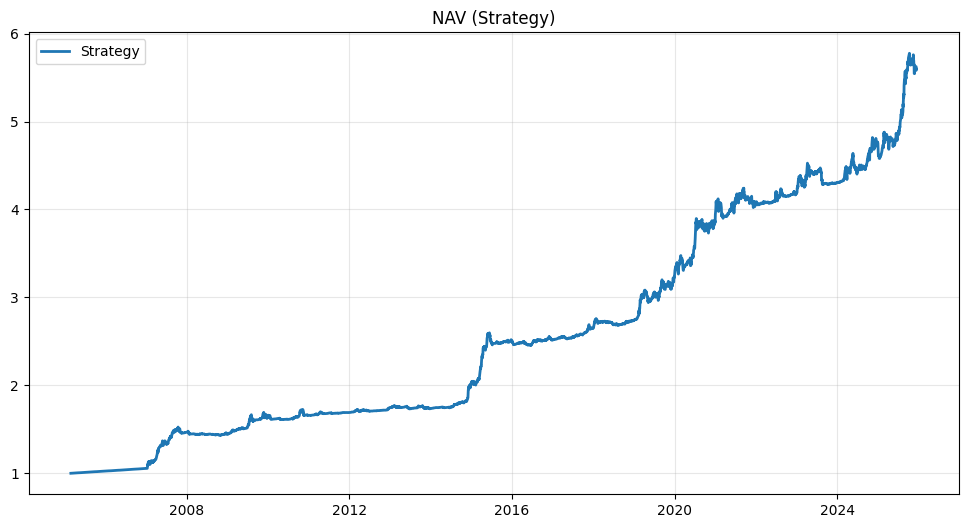

In [55]:
# 策略 NAV
nav_strat = bt_final["nav"].copy()
nav_strat = nav_strat / nav_strat.iloc[0]
plt.figure(figsize=(12,6))
plt.plot(nav_strat.index, nav_strat, label="Strategy", linewidth=2)
plt.legend()
plt.grid(True, alpha=0.3)
plt.title("NAV (Strategy)")
plt.show()

## 对比Baseline

In [56]:
# code: 881001.WI
wind_allA = pd.read_csv("WIND_ALLA_881001.csv", parse_dates=["date"])
wind_allA = wind_allA.sort_values("date").set_index("date")

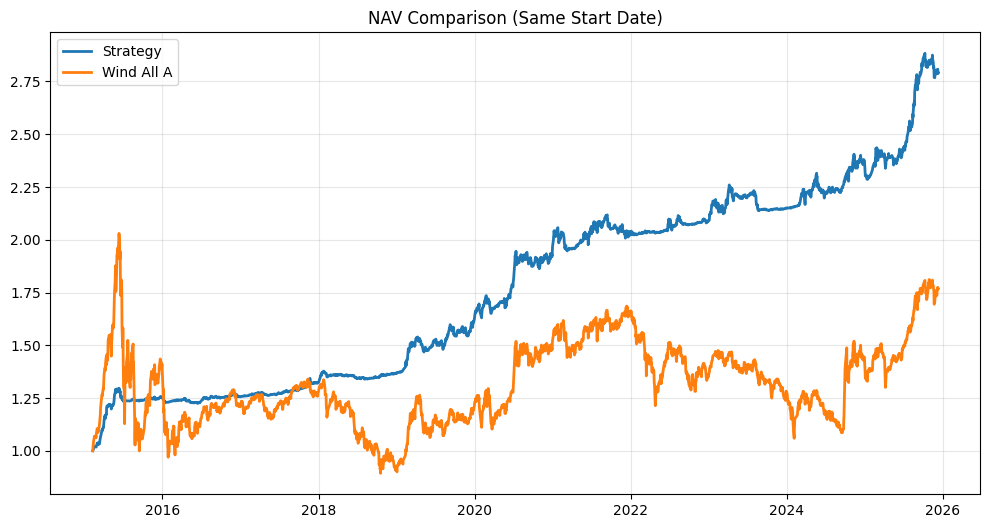

In [57]:
# 策略 NAV
nav_strat = bt_final["nav"].copy()
nav_strat = nav_strat / nav_strat.iloc[0]
START_DATE = "2015-02-09"

# 合并并对齐
nav_cmp = pd.concat(
    [
        nav_strat.rename("Strategy"),
        wind_allA["close"].rename("Wind All A"),
    ],
    axis=1,
    join="inner"
).dropna()

nav_cmp_cut = nav_cmp.loc[START_DATE:].copy()
nav_cmp_cut = nav_cmp_cut / nav_cmp_cut.iloc[0]

# 画图
plt.figure(figsize=(12,6))
plt.plot(nav_cmp_cut.index, nav_cmp_cut["Strategy"], label="Strategy", linewidth=2)
plt.plot(nav_cmp_cut.index, nav_cmp_cut["Wind All A"], label="Wind All A", linewidth=2)
plt.legend()
plt.grid(True, alpha=0.3)
plt.title("NAV Comparison (Same Start Date)")
plt.show()

## Vol Scaling Comparison

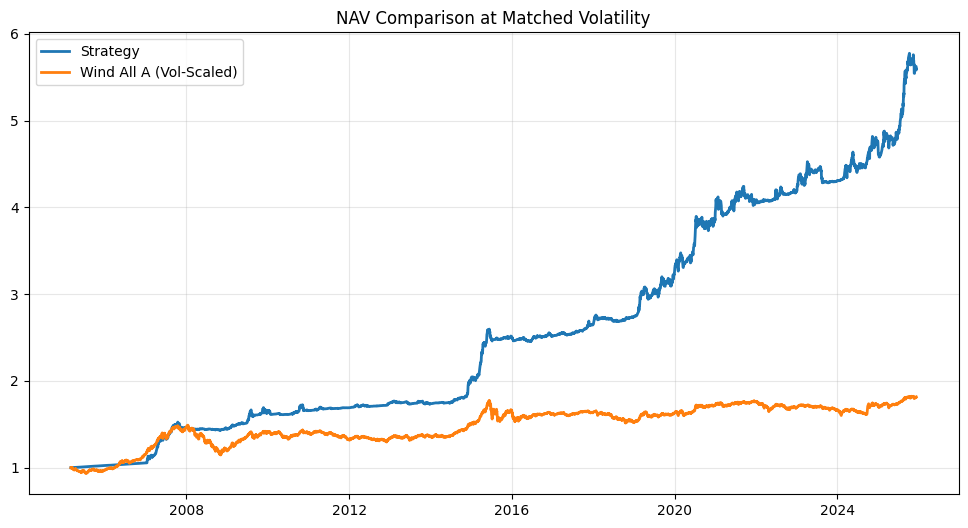

In [58]:
# 策略日收益（用 nav）
ret_strat = nav_cmp["Strategy"].pct_change().dropna()

# Benchmark 日收益
ret_bench = nav_cmp["Wind All A"].pct_change().dropna()

# 对齐（防止日期不一致）
ret = pd.concat([ret_strat, ret_bench], axis=1).dropna()
ret.columns = ["Strategy", "Benchmark"]
ann_factor = 252

vol_strat = ret["Strategy"].std() * np.sqrt(ann_factor)
vol_bench = ret["Benchmark"].std() * np.sqrt(ann_factor)

scale = vol_strat / vol_bench

ret_bench_scaled = ret["Benchmark"] * scale
nav_bench_scaled = (1 + ret_bench_scaled).cumprod()
nav_bench_scaled = nav_bench_scaled / nav_bench_scaled.iloc[0]
nav_cmp_scaled = pd.concat(
    [
        nav_cmp["Strategy"],
        nav_bench_scaled.rename("Wind All A (Vol-Scaled)"),
    ],
    axis=1
).dropna()

nav_cmp_scaled = nav_cmp_scaled / nav_cmp_scaled.iloc[0]

plt.figure(figsize=(12,6))
plt.plot(nav_cmp_scaled.index, nav_cmp_scaled["Strategy"], label="Strategy", linewidth=2)
plt.plot(nav_cmp_scaled.index, nav_cmp_scaled["Wind All A (Vol-Scaled)"], label="Wind All A (Vol-Scaled)", linewidth=2)
plt.legend()
plt.grid(True, alpha=0.3)
plt.title("NAV Comparison at Matched Volatility")
plt.show()

# Build Long-Short Strategy (以下部分为测试LongShort/LongOnly，不需要运行，结论就是LongOnly更好)

In [ ]:
def assign_score_quantile_dynamic(
    df: pd.DataFrame,
    score_col: str = "score",
    target_q: int = 5,
    min_cs: int = 5,      # 少于5只ETF时跳过该日
    mid_cs: int = 15,      # 15~29 -> 3分位
    high_cs: int = 30,     # >=30 -> 5分位
):
    """
    对每个 date 动态选择分位数 q_use，并分组：
      n>=high_cs -> target_q(默认5)
      n>=mid_cs  -> 3
      n>=min_cs  -> 2
      else       -> NaN
    返回：
      q: 每行所属分位(1..q_use)
      q_use: 当日使用的分位数
    """
    q_out = pd.Series(np.nan, index=df.index)
    q_use_out = pd.Series(np.nan, index=df.index)

    for d, g in df.groupby("date"):
        s = g[score_col].dropna()
        n = s.shape[0]
        if n < min_cs:
            continue
        if n >= high_cs:
            q_use = target_q
        elif n >= mid_cs:
            q_use = 3
        else:
            q_use = 2

        r = s.rank(method="first")
        q = pd.qcut(r, q=q_use, labels=False) + 1  # 1..q_use

        q_out.loc[s.index] = q.astype(float)
        q_use_out.loc[g.index] = float(q_use)

    return q_out, q_use_out
panel_with_factors["q"], panel_with_factors["q_use"] = assign_score_quantile_dynamic(
    panel_with_factors, score_col="score"
)

In [ ]:
panel_with_factors.groupby("date")["q"].apply(lambda x: x.notna().sum()).describe()

## Create portfolio weights

In [ ]:
# 按周或月调仓的多空组合权重生成函数
def make_ls_portfolio_weights_dynamic(
    factors: pd.DataFrame,
    freq: str = "W",
    min_universe: int = 5,
    gross: float = 1.0,              # 总杠杆（|w|和），1代表无杠杆，大于1代表有杠杆
    long_short_split: float = 0.95,  # long 占 gross 的比例
    weight_mode: str = "inv_vol",    # "equal" or "inv_vol"
    vol_window: int = 66,
    vol_min_periods: int = 20,
    inv_clip_lower: float = 1e-4,
    inv_clip_mult: float = 5.0,      # inv_vol 上限 = median * mult
) -> pd.DataFrame:

    df = factors.copy()
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values(["code", "date"])

    # rebalance date
    df["reb_date"] = _to_month_end(df["date"]) if freq.upper().startswith("M") else _to_week_end(df["date"])

    # compute vol if needed
    if weight_mode == "inv_vol":
        df["close"] = pd.to_numeric(df["close"], errors="coerce")
        df["ret_1d"] = df.groupby("code")["close"].pct_change()
        df["vol"] = df.groupby("code")["ret_1d"].transform(
            lambda x: x.rolling(vol_window, min_periods=vol_min_periods).std(ddof=0) * np.sqrt(252)
        )

    out = []

    for rd, g in df.groupby("reb_date"):
        # each code: take last obs in the rebalance window
        slice_df = g.sort_values("date").groupby("code", as_index=False).tail(1)

        # require q and q_use
        slice_df = slice_df.dropna(subset=["q", "q_use"])
        if slice_df["code"].nunique() < min_universe:
            continue

        q_use = int(slice_df["q_use"].iloc[0])
        lo_q, hi_q = 1, q_use

        # target gross on each leg
        long_gross = gross * float(long_short_split)
        short_gross = gross * (1.0 - float(long_short_split))

        need_long = long_gross > 0
        need_short = short_gross > 0

        # select legs (allow empty leg if gross=0)
        long_df = slice_df[slice_df["q"] == hi_q].copy() if need_long else slice_df.iloc[0:0].copy()
        short_df = slice_df[slice_df["q"] == lo_q].copy() if need_short else slice_df.iloc[0:0].copy()

        if need_long and len(long_df) == 0:
            continue
        if need_short and len(short_df) == 0:
            continue

        # ------------------------
        # weights inside each leg
        # ------------------------
        parts = []

        if weight_mode == "equal":
            if need_long:
                w_long = np.full(len(long_df), long_gross / len(long_df))
                parts.append(pd.DataFrame({"reb_date": rd, "code": long_df["code"].values, "weight": w_long}))
            if need_short:
                w_short = np.full(len(short_df), -short_gross / len(short_df))
                parts.append(pd.DataFrame({"reb_date": rd, "code": short_df["code"].values, "weight": w_short}))

        elif weight_mode == "inv_vol":
            # drop NaN vol only for the legs that require it
            if need_long:
                long_df = long_df.dropna(subset=["vol"])
                if len(long_df) == 0:
                    continue
            if need_short:
                short_df = short_df.dropna(subset=["vol"])
                if len(short_df) == 0:
                    continue

            if need_long:
                inv_long = 1.0 / long_df["vol"].clip(lower=inv_clip_lower)
                med = np.nanmedian(inv_long.values)
                if np.isfinite(med) and med > 0:
                    inv_long = inv_long.clip(upper=med * inv_clip_mult)
                denom = inv_long.sum()
                if denom <= 0 or not np.isfinite(denom):
                    continue
                w_long = (inv_long / denom) * long_gross
                parts.append(pd.DataFrame({"reb_date": rd, "code": long_df["code"].values, "weight": w_long.values}))

            if need_short:
                inv_short = 1.0 / short_df["vol"].clip(lower=inv_clip_lower)
                med = np.nanmedian(inv_short.values)
                if np.isfinite(med) and med > 0:
                    inv_short = inv_short.clip(upper=med * inv_clip_mult)
                denom = inv_short.sum()
                if denom <= 0 or not np.isfinite(denom):
                    continue
                w_short = -(inv_short / denom) * short_gross
                parts.append(pd.DataFrame({"reb_date": rd, "code": short_df["code"].values, "weight": w_short.values}))

        else:
            raise ValueError("weight_mode must be 'equal' or 'inv_vol'")

        if not parts:
            continue

        tmp = pd.concat(parts, ignore_index=True)

        # diagnostics (rebalance-level fields repeated for convenience)
        tmp["q_use"] = q_use
        tmp["n_long"] = len(long_df) if need_long else 0
        tmp["n_short"] = len(short_df) if need_short else 0
        tmp["gross"] = tmp["weight"].abs().sum()           # should be ~ gross
        tmp["net"] = tmp["weight"].sum()                   # long-biased will be >0
        tmp["long_gross"] = long_gross
        tmp["short_gross"] = short_gross

        out.append(tmp)

    if not out:
        return pd.DataFrame(columns=["reb_date", "code", "weight"])

    return pd.concat(out, ignore_index=True)

In [ ]:
weights_ls = make_ls_portfolio_weights_dynamic(
    panel_with_factors,
    freq="W",
    min_universe=10,
    gross=1.0,
    long_short_split=0.95,
    weight_mode="inv_vol",
    vol_window=66,
    vol_min_periods=20,
    inv_clip_lower=1e-4,
    inv_clip_mult=5.0,
)

## Backtest results

In [ ]:
etf_cls = pq.read_table("ChinaETFInvestClass.parquet").to_pandas()
cash_etf = etf_cls[etf_cls["S_INFO_NAME"] == "货币型ETF"]

In [ ]:
cash_etf_codes = cash_etf["S_INFO_WINDCODE"].astype(str).unique()
cash_etf_codes

In [ ]:
panel_cash = panel[panel["code"].isin(cash_etf_codes)]
panel_cash

panel 里面没有货币etf，所以使用虚拟资金代替，年化收益率设为3%。

In [ ]:
bt = backtest_from_weights(panel, weights_ls, cost_bps=5.0, exec_lag=1)

print(bt[["net_expo", "gross_expo"]].describe())
print("Min daily net ret:", bt["ret_net"].min())

在修复调仓日仓位重叠问题后，当前的多空回测引擎在工程和经济含义上均表现出一致且合理的行为。组合在全样本期内始终保持接近零的净敞口，验证了严格的市场中性特征；同时，组合的总敞口稳定受控于目标水平（gross ≈ 1），未再出现非预期的杠杆放大或仓位叠加现象。日度收益的尾部分布处于合理区间，表明回测过程中不存在未来函数或隐含杠杆风险。整体来看，该框架能够正确处理执行滞后、动态分位构建、基于换手率的交易成本以及敞口监控问题，为在高度非平稳的 ETF 横截面环境下评估因子有效性提供了可靠的回测基础。

In [ ]:
import matplotlib.pyplot as plt

nav_plot = bt["nav"].where(bt["nav"] > 0)
plt.figure(figsize=(12,6))
plt.plot(nav_plot.index, nav_plot, label="LS Strategy (Net)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

净值在样本早期长期横盘，主要反映 ETF 市场尚未成熟、横截面规模不足，策略在动态分位规则下大部分时间选择不交易；2011–2013 年左右随着 ETF 数量和流动性显著提升，策略开始稳定运行，净值出现一次明显的结构性跃迁，这并非异常收益，而是从“几乎空仓”过渡到“持续持仓”的自然结果。此后净值走势呈现典型的多空策略特征：在 2014–2016 年阶段性放大，在随后几年进入震荡与回撤并存的状态，但整体维持正的长期累积收益。曲线不存在爆炸式上涨或突然归零的异常形态，说明回测中未引入隐含杠杆、未来函数或仓位叠加问题，收益主要来源于横截面排序信号本身而非工程性偏差。

## 划分时间段(2010-)

In [ ]:
START_DATE = "2010-01-01"

panel_2010 = panel[panel["date"] >= START_DATE].copy()
weights_2010 = weights_ls[weights_ls["reb_date"] >= START_DATE].copy()

bt_2010 = backtest_from_weights(
    panel_2010,
    weights_2010,
    cost_bps=5.0,
    exec_lag=1,
)
summary_2010 = performance_summary(bt_2010)
summary_2010

In [ ]:
# 画图对比
nav_plot_2010 = bt_2010["nav"].where(bt_2010["nav"] > 0)
plt.figure(figsize=(12,6))
plt.plot(nav_plot_2010.index, nav_plot_2010, label="LS Strategy (Net) 2010-")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

自 2010 年起，在中国 ETF 市场进入相对成熟阶段后，基于量价信号的分位多空策略展现出持续的正向累积收益。策略在多个市场周期中均能产生 alpha，尤其在趋势分化和成交量显著扩张的阶段表现突出；在高波动或政策主导的市场环境中虽出现阶段性回撤，但多空结构有效限制了系统性风险。整体来看，该策略的收益更多来源于横截面排序能力而非方向性暴露，具备一定的结构稳定性与跨周期适用性。

## 对比多种参数组合

In [ ]:
def run_ls_nav_experiments_2010(
    panel: pd.DataFrame,
    factors: pd.DataFrame,
    splits=(0.5, 0.75, 0.8, 0.95, 1.0),
    modes=("inv_vol", "equal"),
    freq: str = "W",
    min_universe: int = 10,
    gross: float = 1.0,
    vol_window: int = 66,
    cost_bps: float = 5.0,
    exec_lag: int = 1,
    compare_split: float = 0.95,     # inv_vol vs equal 用哪个 split
    logy: bool = False,
):
    """
    Run NAV comparisons for LS strategy using data >= 2010-01-01 only.
    """

    START_DATE = pd.Timestamp("2010-01-01")

    # -----------------------
    # 1) Restrict sample to 2010+
    # -----------------------
    panel_ = panel.copy()
    panel_["date"] = pd.to_datetime(panel_["date"])
    panel_ = panel_[panel_["date"] >= START_DATE].copy()

    factors_ = factors.copy()
    factors_["date"] = pd.to_datetime(factors_["date"])
    factors_ = factors_[factors_["date"] >= START_DATE].copy()

    results = {}
    summary_rows = []

    # -----------------------
    # 2) Run experiments
    # -----------------------
    for mode in modes:
        for sp in splits:
            w = make_ls_portfolio_weights_dynamic(
                factors_,
                freq=freq,
                min_universe=min_universe,
                gross=gross,
                long_short_split=float(sp),
                weight_mode=mode,
                vol_window=vol_window,
            )

            bt = backtest_from_weights(
                panel_,
                w,
                cost_bps=cost_bps,
                exec_lag=exec_lag,
            )

            bt = bt.dropna(subset=["nav"]).copy()
            if len(bt) == 0:
                continue

            bt["nav_norm"] = bt["nav"] / bt["nav"].iloc[0]

            key = (mode, float(sp))
            results[key] = bt

            s = performance_summary(bt)
            s["mode"] = mode
            s["split"] = float(sp)
            s["curve"] = f"{mode}|split={sp:g}"
            summary_rows.append(s)

    summary_df = (
        pd.DataFrame(summary_rows)
        .set_index("curve")
        .sort_values(["mode", "split"])
    )

    # -----------------------
    # 3) Build NAV panel
    # -----------------------
    nav_panel = pd.concat(
        {k[0] + "|split=" + str(k[1]): v["nav_norm"] for k, v in results.items()},
        axis=1
    ).sort_index()

    # -----------------------
    # 4) Plot: split comparison (per mode)
    # -----------------------
    for mode in modes:
        cols = [c for c in nav_panel.columns if c.startswith(f"{mode}|split=")]
        if not cols:
            continue

        plt.figure(figsize=(12, 6))
        for c in cols:
            plt.plot(nav_panel.index, nav_panel[c], label=c.split("|")[1], linewidth=2)
        plt.title(f"NAV across long_short_split ({mode}, 2010+)")
        if logy:
            plt.yscale("log")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    # -----------------------
    # 5) Plot: inv_vol vs equal (fixed split)
    # -----------------------
    plt.figure(figsize=(12, 6))
    for mode in modes:
        col = f"{mode}|split={compare_split:g}"
        if col in nav_panel.columns:
            plt.plot(nav_panel.index, nav_panel[col], label=col, linewidth=2)
    plt.title(f"NAV: inv_vol vs equal (split={compare_split:g}, 2010+)")
    if logy:
        plt.yscale("log")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return results, nav_panel, summary_df

In [ ]:
results, nav_panel, summary_df = run_ls_nav_experiments_2010(
    panel=panel,
    factors=panel_with_factors,
    splits=(0.5, 0.75, 0.8, 0.95, 1.0), # try multiple splits
    modes=("inv_vol", "equal"),
    min_universe=10,
    gross=1.0,
    vol_window=22,
    cost_bps=5.0, # 交易成本：5bps
    exec_lag=1,
    compare_split=0.95,
    logy=False
)

summary_df

表中结果进一步验证了多空敞口配置与权重方案对策略绩效的系统性影响。无论采用等权（equal）还是逆波动率加权（inv_vol），组合的年化收益率与 Sharpe Ratio 均随多头占比的提高而显著改善，且在高多头占比（0.8–1.0）区间表现最为稳健。相较于等权方案，inv_vol 配置在几乎所有敞口设置下均实现了更高的风险调整后收益，表现为更高的 Sharpe Ratio 和更可控的最大回撤，表明风险加权在 ETF 横截面中具有明显的组合层面优势。同时可以观察到，严格市场中性（split=0.5）配置下的年化收益和 Sharpe 均显著偏低，而接近多头-only 的配置在保持合理波动和回撤水平的同时实现了最佳长期表现。这一结果说明，策略的收益主要由多头端驱动，适度放松市场中性约束并结合逆波动率权重，有助于在不显著放大风险的前提下提升组合整体的风险收益特征。